In [ ]:
import torch
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt

In [3]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

# Import dataset from PyTorch Geometric
dataset = Planetoid(root='data/Planetoid', name='Cora', transform=NormalizeFeatures())

# Print information
print(dataset)
print('------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print first element
print(f'Graph: {dataset[0]}')

/home/filipe/miniconda3/envs/redes_grafos/lib/python3.14/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._show_config()
/home/filipe/miniconda3/envs/redes_grafos/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cora()
------------
Number of graphs: 1
Number of features: 1433
Number of classes: 7
Graph: Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [4]:
data = dataset[0]

print(f'x = {data.x.shape}')
print(data.x)

x = torch.Size([2708, 1433])
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


In [5]:
print(f'edge_index = {data.edge_index.shape}')
print(data.edge_index)

edge_index = torch.Size([2, 10556])
tensor([[ 633, 1862, 2582,  ...,  598, 1473, 2706],
        [   0,    0,    0,  ..., 2707, 2707, 2707]])


In [6]:
from torch_geometric.utils import to_dense_adj

A = to_dense_adj(data.edge_index)[0].numpy().astype(int)
print(f'A = {A.shape}')
print(A)

A = (2708, 2708)
[[0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 0]]


In [7]:
print(f'y = {data.y.shape}')
print(data.y)

y = torch.Size([2708])
tensor([3, 4, 4,  ..., 3, 3, 3])


In [8]:
print(f'train_mask = {data.train_mask.shape}')
print(data.train_mask)

train_mask = torch.Size([2708])
tensor([ True,  True,  True,  ..., False, False, False])


In [9]:
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

Edges are directed: False
Graph has isolated nodes: False
Graph has loops: False


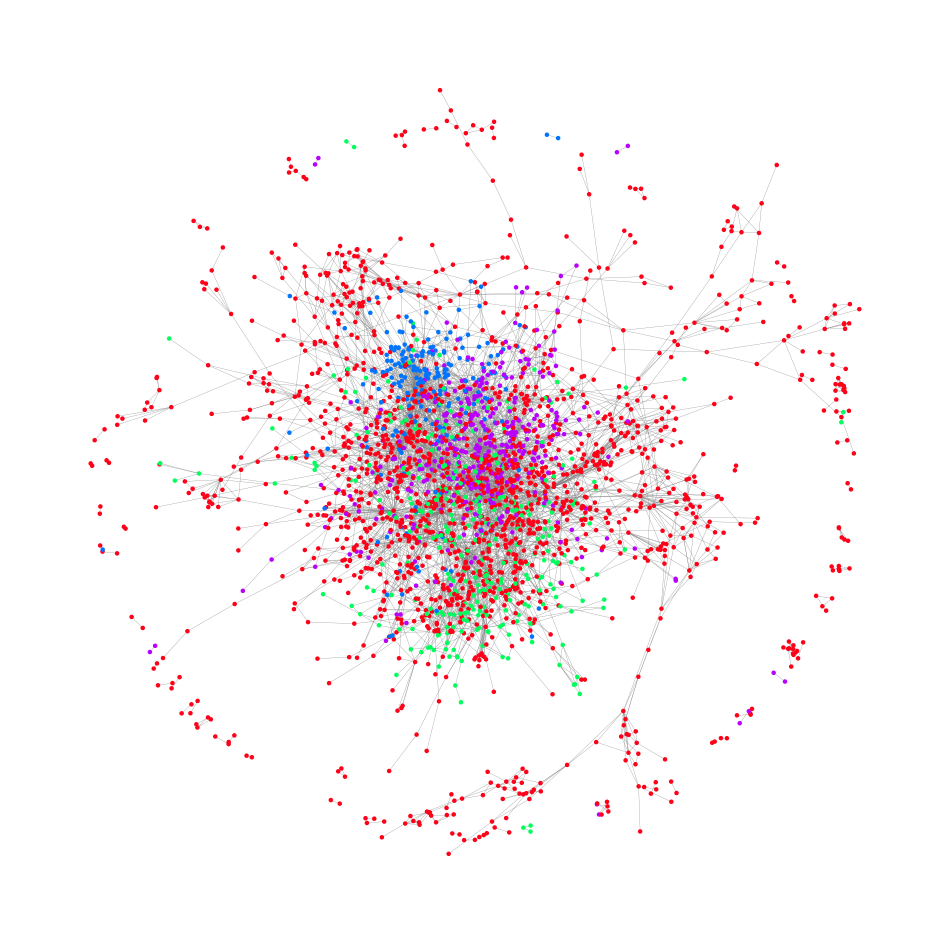

In [10]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
plt.figure(figsize=(12,12))
plt.axis('off')
nx.draw_networkx(G,
                pos=nx.spring_layout(G, seed=0),
                with_labels=False,
                node_size=5,
                node_color=data.y,
                cmap="hsv",
                vmin=-2,
                vmax=3,
                width=0.2,
                edge_color="grey",
                font_size=0
                )
plt.show()

In [80]:
from torch_geometric.nn import GCNConv
from torch.nn import Linear
import torch.nn.functional as F

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gcn1 = GCNConv(dataset.num_features, 16) 
        self.gcn2 = GCNConv(16, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.gcn1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.7, training=self.training)
        x = self.gcn2(x, edge_index)
        return x

model = GCN()
print(model)

GCN(
  (gcn1): GCNConv(1433, 16)
  (gcn2): GCNConv(16, 7)
)


In [39]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

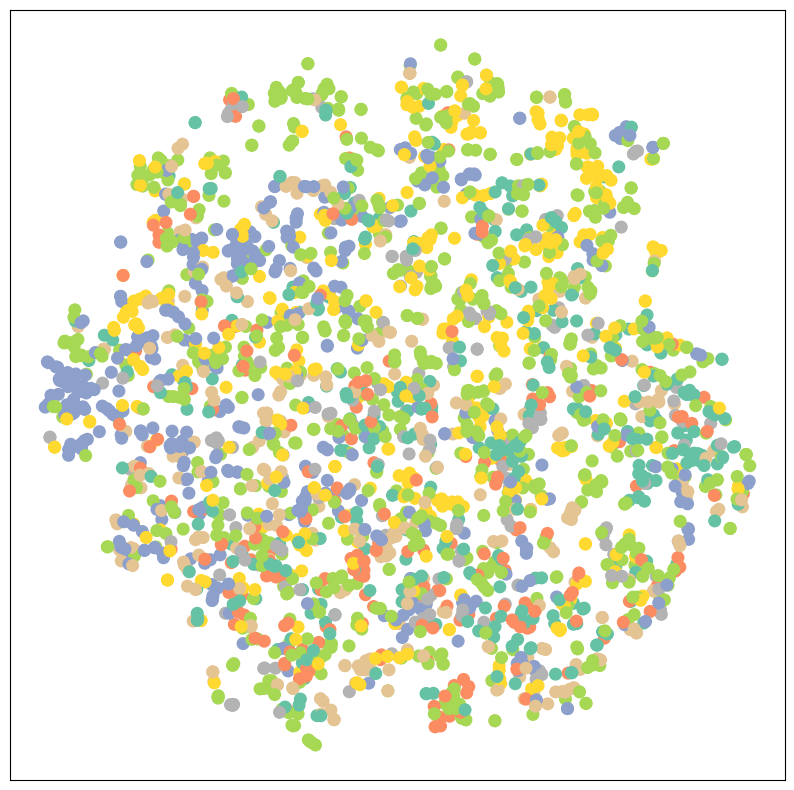

In [13]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

In [ ]:
model = GCN()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01,weight_decay=5e-4)

train_losses = []
val_losses = []
# Calculate accuracy
def accuracy(pred_y, y):
    return (pred_y == y).sum() / len(y)

def train():# Training loop
    # Clear gradients
    optimizer.zero_grad()

    # Forward pass
    out = model(data.x, data.edge_index)

    # Calculate loss function
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    # Calculate accuracy
    acc = accuracy(out.argmax(dim=1)[data.train_mask], data.y[data.train_mask])

    # Compute gradients
    loss.backward()

    # Tune parameters
    optimizer.step()

    return loss.item(), acc.item()

def evaluate():
    model.eval() 
    with torch.no_grad(): 
        out_val = model(data.x, data.edge_index)
        val_loss = criterion(out_val[data.val_mask], data.y[data.val_mask])
    return val_loss.item()

for epoch in range(200):
    loss , acc = train()
    
    val_los = evaluate()
    
    train_losses.append(loss)
    val_losses.append(val_los)  
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | ValLoss: {val_los:.2f} | Acc: {acc*100:.2f}%')

Epoch   0 | Loss: 1.95 | ValLoss: 1.95 | Acc: 9.29%
Epoch  10 | Loss: 1.87 | ValLoss: 1.90 | Acc: 89.29%
Epoch  20 | Loss: 1.72 | ValLoss: 1.82 | Acc: 95.71%
Epoch  30 | Loss: 1.51 | ValLoss: 1.70 | Acc: 97.14%
Epoch  40 | Loss: 1.27 | ValLoss: 1.56 | Acc: 96.43%
Epoch  50 | Loss: 1.03 | ValLoss: 1.42 | Acc: 97.14%
Epoch  60 | Loss: 0.83 | ValLoss: 1.29 | Acc: 98.57%
Epoch  70 | Loss: 0.68 | ValLoss: 1.18 | Acc: 98.57%
Epoch  80 | Loss: 0.57 | ValLoss: 1.10 | Acc: 98.57%
Epoch  90 | Loss: 0.49 | ValLoss: 1.04 | Acc: 98.57%
Epoch 100 | Loss: 0.44 | ValLoss: 0.99 | Acc: 98.57%
Epoch 110 | Loss: 0.39 | ValLoss: 0.96 | Acc: 98.57%
Epoch 120 | Loss: 0.36 | ValLoss: 0.93 | Acc: 99.29%
Epoch 130 | Loss: 0.33 | ValLoss: 0.90 | Acc: 99.29%
Epoch 140 | Loss: 0.31 | ValLoss: 0.88 | Acc: 100.00%
Epoch 150 | Loss: 0.29 | ValLoss: 0.87 | Acc: 100.00%
Epoch 160 | Loss: 0.28 | ValLoss: 0.85 | Acc: 100.00%
Epoch 170 | Loss: 0.26 | ValLoss: 0.84 | Acc: 100.00%
Epoch 180 | Loss: 0.25 | ValLoss: 0.83 | Ac

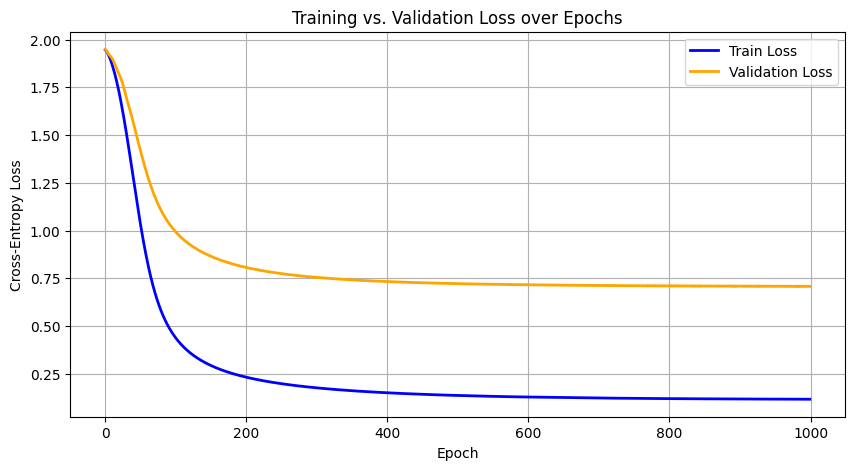

In [95]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [96]:
def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    test_correct = pred[data.test_mask] == data.y[data.test_mask]
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
    return test_acc

test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.8070


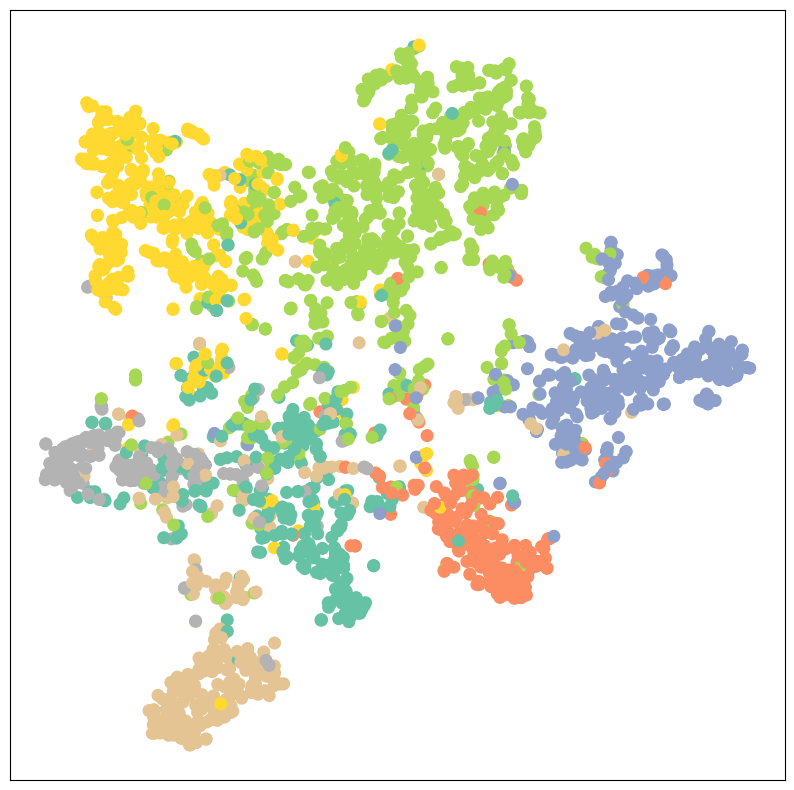

In [16]:
model.eval()
out = model(data.x, data.edge_index)
visualize(out, color=data.y)